# **Lab 05.2 - Continuous and Policy-Based RL with DDPG and PPO**


##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
  
This lab contains the following practical parts:
1. Part 1,2 — Build and validate the EdgeOffloadingEnv (device vs. edge).
2. Part 3 — Implement baseline policies (random, device-only, edge-only, greedy).
3. Part 4 — A2C
4. Part 5 — PPO
6. Part 6 — Final comparison and analysis of all methods.


In [19]:
# ============================================================================
# Imports and runtime stability config
# ============================================================================

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# Limit PyTorch threading for kernel stability on macOS
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

# Reproducibility
SEED = 42
FAST_MODE = False
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device info
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Gymnasium: {gym.__version__}')
print(f'FAST_MODE: {FAST_MODE}')

# Shared plotting helpers
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

def moving_average(values, window=20):
    """Smooth a learning curve using a moving average."""
    if len(values) == 0:
        return np.array([])
    return pd.Series(values).rolling(window=window, min_periods=1).mean().to_numpy()


def plot_curve(values, title, ylabel, window=20):
    """Plot raw values together with a moving average."""
    x = np.arange(1, len(values) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(x, values, alpha=0.35, label='Episode value')
    plt.plot(x, moving_average(values, window), lw=2, label=f'{window}-episode moving average')
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_edge_policy(env_fn, action_fn, episodes=100):
    """Evaluate a policy on EdgeOffloadingEnv and return summary metrics."""
    episode_rewards, episode_avg_latencies, all_latencies = [], [], []
    action_counts = np.zeros(2, dtype=np.int64)

    for ep in range(episodes):
        env = env_fn(SEED + 2000 + ep)
        state, _ = env.reset(seed=SEED + 2000 + ep)

        done = False
        rewards, latencies = [], []

        while not done:
            action = int(action_fn(state, env))
            state, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            latencies.append(info['latency'])
            action_counts[action] += 1
            done = terminated or truncated

        env.close()
        episode_rewards.append(float(np.sum(rewards)))
        episode_avg_latencies.append(float(np.mean(latencies)))
        all_latencies.extend(latencies)

    all_latencies = np.array(all_latencies, dtype=np.float32)
    total_actions = int(action_counts.sum())

    return {
        'episode_rewards': np.array(episode_rewards, dtype=np.float32),
        'episode_avg_latencies': np.array(episode_avg_latencies, dtype=np.float32),
        'all_latencies': all_latencies,
        'action_counts': action_counts,
        'avg_latency': float(np.mean(all_latencies)),
        'p95_latency': float(np.percentile(all_latencies, 95)),
        'avg_reward': float(np.mean(episode_rewards)),
        'device_pct': float(action_counts[0] / total_actions * 100.0),
        'edge_pct': float(action_counts[1] / total_actions * 100.0),
    }

Device: cuda
PyTorch: 2.5.1+cu121
NumPy: 2.4.3
Gymnasium: 1.2.3
FAST_MODE: False


In [20]:
print("\n" + "="*60)
print("PART 1: EDGE OFFLOADING ENVIRONMENT")
print("="*60)

class EdgeOffloadingEnv(gym.Env):
    """Custom edge offloading environment for RL training.
    
    State: [input_size, workload, uplink_rate, edge_queue]
    Actions: 0 = device execution, 1 = edge offloading
    Reward: -latency (minimizing latency)
    """

    metadata = {'render_modes': ['human']}

    def __init__(self, max_steps=50):
        """Initialize environment parameters.
        
        Args:
            max_steps: Maximum steps per episode
        """
        super().__init__()
        
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.max_steps = max_steps

        self.f_device = 1.0
        self.f_edge = 5.0

        self.action_space = spaces.Discrete(2)

        low_bound = np.array([1.0, 0.1, 2.0, 0.0], dtype=np.float32)
        high_bound = np.array([20.0, 3.0, 20.0, 200.0], dtype=np.float32)
        self.observation_space = spaces.Box(
            low=low_bound,
            high=high_bound,
            dtype=np.float32
        )
        self.state = None
        self.step_count = 0


    def _sample_state(self):
        """Sample a new random state.
        
        Returns:
            State array: [input_size, workload, uplink_rate, edge_queue]
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        input_side = np.random.uniform(1.0, 20.0)
        workload = np.random.uniform(0.1, 3.0)
        uplink_rate = np.random.uniform(2.0, 20.0)
        edge_queue = np.random.uniform(0.0, 200.0)
        return np.array([input_side, workload, uplink_rate, edge_queue], dtype=np.float32)

    def _compute_latencies(self, state):
        """Compute execution latencies for device and edge.
        
        Args:
            state: Current state [input_size, workload, uplink_rate, edge_queue]
            
        Returns:
            Tuple (latency_device, latency_edge) in milliseconds
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        input_size, workload, uplink_rate, edge_queue = state
        t_device = (workload / self.f_device) * 1000.0
        t_upload = (input_size / uplink_rate) * 1000.0
        t_edge = t_upload + edge_queue + (workload / self.f_edge) * 1000.0
        return t_device, t_edge

    def reset(self, seed=None, options=None):
        """Reset environment to initial state.
        
        Args:
            seed: Random seed for reproducibility
            options: Additional reset options
            
        Returns:
            Tuple (observation, info)
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.step_count = 0
        self.state = self._sample_state()
        info = {}
        return self.state, info

    def step(self, action):
        """Execute one step in the environment.
        
        Args:
            action: 0 for device execution, 1 for edge offloading
            
        Returns:
            Tuple (observation, reward, terminated, truncated, info)
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        assert self.action_space.contains(action), f"Invalid action: {action}"
        t_device, t_edge = self._compute_latencies(self.state)

        if action == 0:
            selected_latency = t_device
            action_name = 'device'
        else:
            selected_latency = t_edge
            action_name = 'edge'

        reward = -(selected_latency / 1000.0)
        self.step_count += 1

        terminated = False
        truncated = bool(self.step_count >= self.max_steps)

        info = {
            'latency': selected_latency,
            't_device': t_device,
            't_edge': t_edge,
            'action_name': action_name,
            'action': int(action)
        }

        # Transition to a new state so agent can observe dynamics
        self.state = self._sample_state()

        return self.state, reward, terminated, truncated, info

    def render(self):
        """Render current environment state."""
        if self.state is None:
            print('Environment has not been reset yet.')
        else:
            print(f'Step {self.step_count:02d} | state = {np.round(self.state, 3)}')


# Test environment initialization
print("\nInitializing EdgeOffloadingEnv...")
edge_env = EdgeOffloadingEnv(max_steps=50)
obs, info = edge_env.reset(seed=SEED)
print(f'Initial observation: {np.round(obs, 3)}')
print(f'Initial info: {info}')


PART 1: EDGE OFFLOADING ENVIRONMENT

Initializing EdgeOffloadingEnv...
Initial observation: [  8.116   2.857  15.176 119.732]
Initial info: {}


---

# PART 2: Environment Validation

Before training any policy, we validate environment API behavior and inspect transition outputs using a short random rollout.

In [21]:
# Environment validation and simple rollout test
print("\nValidating environment...")
try:
    from gymnasium.utils.env_checker import check_env
    check_env(edge_env, skip_render_check=True)
    print("✓ check_env passed successfully.")
except Exception as exc:
    print(f"check_env not available or skipped. Details: {exc}")

# Run a few steps to verify correctness
print("\nTest rollout (5 steps):")
obs, info = edge_env.reset(seed=SEED)
print(f"Initial obs: {np.round(obs, 3)}")

for step_idx in range(5):
    action = edge_env.action_space.sample()
    obs, reward, terminated, truncated, info = edge_env.step(action)
    print(f"Step {step_idx + 1}: action={action}, "
          f"reward={reward:.6f}, "
          f"latency={info['latency']:.2f}ms, "
          f"action_name={info['action_name']}")
    
    if terminated or truncated:
        obs, info = edge_env.reset(seed=SEED + step_idx + 1)
        print("  → Episode truncated, reset.")



Validating environment...
check_env not available or skipped. Details: Expects the random number generator to have been generated given a seed was passed to reset. Most likely the environment reset function does not call `super().reset(seed=seed)`.

Test rollout (5 steps):
Initial obs: [16.816  0.716  5.273 36.681]
Step 1: action=0, reward=-0.715783, latency=715.78ms, action_name=device
Step 2: action=0, reward=-1.621794, latency=1621.79ms, action_name=device
Step 3: action=1, reward=-1.913522, latency=1913.52ms, action_name=edge
Step 4: action=0, reward=-2.377010, latency=2377.01ms, action_name=device
Step 5: action=0, reward=-0.234706, latency=234.71ms, action_name=device


---

# PART 3: Baseline Policies and Evaluation

Before training RL algorithms, we establish baseline policies to understand expected latency and reward scales.

### 3.1 Policy Implementations

We implement four baseline policies:
- **Random**: choose action uniformly at random
- **Device-only**: always execute on device
- **Edge-only**: always offload to edge
- **Greedy latency**: choose action with lower immediate latency


In [22]:
# ============================================================================
# Baseline policy functions
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
def random_policy(state, env):
    return env.action_space.sample()
def device_only_policy(state, env):
    return 0
def edge_only_policy(state, env):
    return 1
def greedy_latency_policy(state, env):
    t_device, t_edge = env._compute_latencies(state)
    return 0 if t_device <= t_edge else 1

In [23]:
# ============================================================================
# Evaluate baseline policies
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
env_fn = lambda seed: EdgeOffloadingEnv(max_steps=50)
policies = {
    'Random': random_policy,
    'Device Only': device_only_policy,
    'Edge Only': edge_only_policy,
    'Greedy Latency': greedy_latency_policy
}
baseline_results = {}
print("\nEvaluating baseline policies...")
for name, policy_fn in policies.items():
    print(f"Evaluating {name} policy...")
    results = evaluate_edge_policy(env_fn, policy_fn, episodes=100)
    baseline_results[name] = results
    print(f"  → Avg Reward: {results['avg_reward']:.4f}, "
          f"Avg Latency: {results['avg_latency']:.2f}ms, "
          f"P95 Latency: {results['p95_latency']:.2f}ms, "
          f"Device %: {results['device_pct']:.1f}%, "
          f"Edge %: {results['edge_pct']:.1f}%")


Evaluating baseline policies...
Evaluating Random policy...
  → Avg Reward: -82.2285, Avg Latency: 1644.57ms, P95 Latency: 3269.92ms, Device %: 50.6%, Edge %: 49.4%
Evaluating Device Only policy...
  → Avg Reward: -76.7208, Avg Latency: 1534.42ms, P95 Latency: 2861.96ms, Device %: 100.0%, Edge %: 0.0%
Evaluating Edge Only policy...
  → Avg Reward: -87.5733, Avg Latency: 1751.47ms, P95 Latency: 4604.03ms, Device %: 0.0%, Edge %: 100.0%
Evaluating Greedy Latency policy...
  → Avg Reward: -56.8970, Avg Latency: 1137.94ms, P95 Latency: 2360.76ms, Device %: 49.5%, Edge %: 50.5%


---

# PART 4: A2C 


### 6.1 A2C Training and Evaluation



PART 4: A2C (TUNED HYPERPARAMS)
Using cpu device
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 50       |
|    ep_rew_mean        | -72.4    |
| time/                 |          |
|    fps                | 2324     |
|    iterations         | 100      |
|    time_elapsed       | 1        |
|    total_timesteps    | 4000     |
| train/                |          |
|    entropy_loss       | -0.539   |
|    explained_variance | 0.0797   |
|    learning_rate      | 0.0003   |
|    n_updates          | 99       |
|    policy_loss        | -2.76    |
|    value_loss         | 16.5     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 50       |
|    ep_rew_mean        | -65.3    |
| time/                 |          |
|    fps                | 2359     |
|    iterations         | 200      |
|    time_elapsed       | 3        |
|    total_timesteps    |

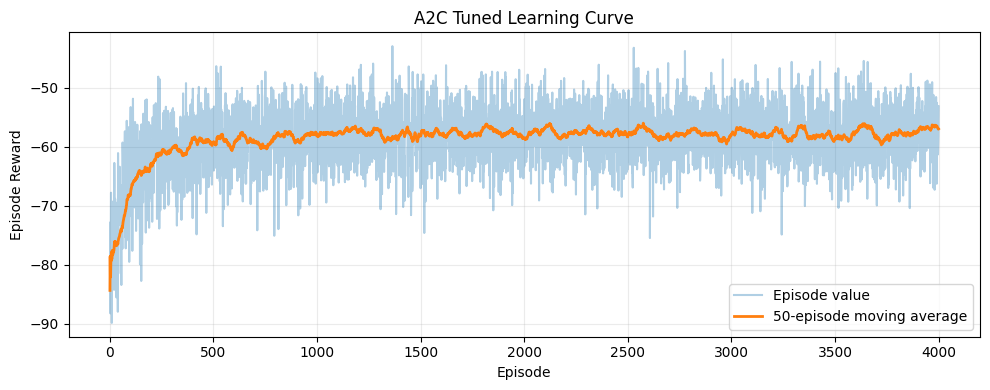

A2C tuned evaluation (mean reward over 50 vec-steps): -58.9170


In [26]:
# ============================================================================
# A2C training and evaluation (hyperparameter tuning)
# ============================================================================

print("\n" + "=" * 60)
print("PART 4: A2C (TUNED HYPERPARAMS)")
print("=" * 60)

from stable_baselines3 import A2C
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, BaseCallback, CallbackList
from stable_baselines3.common.env_util import make_vec_env


class EpisodeRewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        for info in infos:
            if isinstance(info, dict) and "episode" in info:
                self.episode_rewards.append(float(info["episode"]["r"]))
        return True


# env factory wrapped with Monitor for proper episode logging
def make_env():
    env = EdgeOffloadingEnv(max_steps=50)
    return Monitor(env)

n_envs = 8
# tuned hyperparams
# keep a moderate budget during testing; increase outside notebook for final runs
total_timesteps = 200000

# use VecNormalize to standardize observations; avoid normalizing rewards to reduce noise
vec_env = make_vec_env(make_env, n_envs=n_envs, seed=SEED)
vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=False)

policy_kwargs = dict(net_arch=[128, 128])
model = A2C(
    policy="MlpPolicy",
    env=vec_env,
    verbose=1,
    seed=SEED,
    device="cpu",
    learning_rate=3e-4,
    ent_coef=0.01,
    gamma=0.99,
    gae_lambda=0.95,
    n_steps=5,  # per-environment steps (n_envs * n_steps total rollout)
    policy_kwargs=policy_kwargs,
)

# evaluation callback: create a VecNormalize-wrapped eval env to match training wrapper
eval_env = make_vec_env(lambda: Monitor(EdgeOffloadingEnv(max_steps=50)), n_envs=1, seed=SEED)
eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, training=False)
eval_callback = EvalCallback(eval_env, best_model_save_path="./logs/a2c_best", eval_freq=5000, n_eval_episodes=10, deterministic=True)
checkpoint_callback = CheckpointCallback(save_freq=5000, save_path='./logs/a2c_ckpt', name_prefix='a2c')
reward_callback = EpisodeRewardCallback()
callback = CallbackList([reward_callback, eval_callback, checkpoint_callback])

model.learn(total_timesteps=total_timesteps, callback=callback)
model.save("a2c_edgeoffloading_tuned_hp")

# plot learning curve
if len(reward_callback.episode_rewards) > 0:
    plot_curve(reward_callback.episode_rewards, title="A2C Tuned Learning Curve", ylabel="Episode Reward", window=50)

# unwrap VecNormalize for evaluation
vec_env.training = False
vec_env.norm_reward = False

# reload best model if exists else use current
try:
    model = A2C.load("./logs/a2c_best/best_model.zip", env=vec_env)
except Exception:
    model = A2C.load("a2c_edgeoffloading_tuned_hp", env=vec_env)

# short evaluation
obs = vec_env.reset()
eval_steps = 50
episode_rewards = np.zeros(n_envs, dtype=np.float32)
for _ in range(eval_steps):
    action, _states = model.predict(obs, deterministic=True)
    obs, rewards, dones, infos = vec_env.step(action)
    episode_rewards += rewards

print(f"A2C tuned evaluation (mean reward over {eval_steps} vec-steps): {episode_rewards.mean():.4f}")

---

# PART 5: PPO on EdgeOffloadingEnv

**Pipeline Architecture**:
1. Feed edge state tensors into shared feature blocks.
2. Produce offloading-action logits via `ppo_scratch_policy_net`.
3. Produce scalar baseline via `ppo_scratch_value_net`.
4. Sample actions from Categorical logits for on-policy exploration.

**Component Interactions**:
- Policy and value heads share encoded system-state features.
- Outputs are consumed by rollout collection and PPO optimization below.

**Mathematical/Algorithmic Anchors**:
- Categorical stochastic policy over offloading decisions.
- Baseline value estimate for advantage reduction.



PART 5: PPO (HYPERPARAM TUNING FOR GREEDY MATCH)
Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -82      |
| time/              |          |
|    fps             | 3872     |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 16384    |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 50          |
|    ep_rew_mean          | -80.1       |
| time/                   |             |
|    fps                  | 1609        |
|    iterations           | 2           |
|    time_elapsed         | 20          |
|    total_timesteps      | 32768       |
| train/                  |             |
|    approx_kl            | 0.001794942 |
|    clip_fraction        | 0.0864      |
|    clip_range           | 0.1         |
|    entropy_loss         | -0.691      |
|    

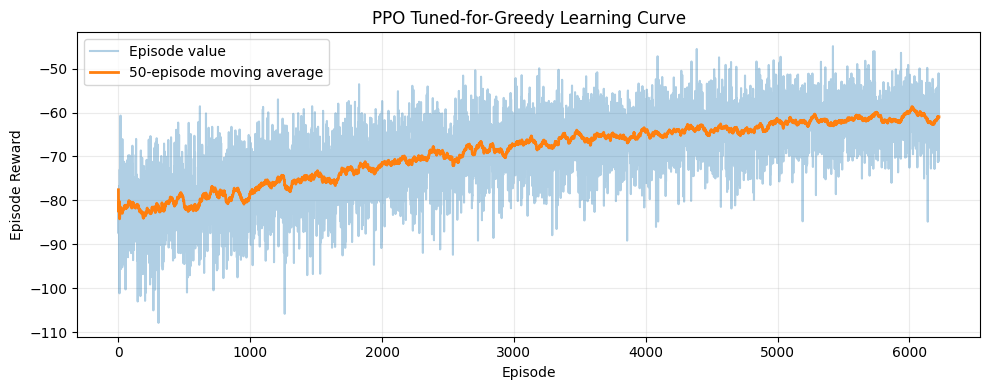

PPO tuned-for-greedy evaluation (mean reward over 50 vec-steps): -58.9113


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [31]:
print("\n" + "="*60)
print("PART 5: PPO (HYPERPARAM TUNING FOR GREEDY MATCH)")
print("="*60)

# ============================================================================
# PPO tuning: increase exploration and network capacity to better match Greedy
# ============================================================================

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, BaseCallback, CallbackList
from stable_baselines3.common.env_util import make_vec_env


class EpisodeRewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        for info in infos:
            if isinstance(info, dict) and "episode" in info:
                self.episode_rewards.append(float(info["episode"]["r"]))
        return True


def make_env():
    env = EdgeOffloadingEnv(max_steps=50)
    return Monitor(env)

n_envs = 8
ppo_timesteps = 300000
vec_env = make_vec_env(make_env, n_envs=n_envs, seed=SEED)
# keep observation normalization, avoid normalizing reward (reward = -latency)
vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=False)

policy_kwargs = dict(net_arch=[256, 256])
model = PPO(
    policy="MlpPolicy",
    env=vec_env,
    verbose=1,
    seed=SEED,
    device="cpu",
    learning_rate=1e-4,
    n_steps=2048,
    batch_size=128,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.1,
    ent_coef=0.02,     # increase entropy to encourage exploration (try to discover greedy-like choices)
    vf_coef=0.5,
    policy_kwargs=policy_kwargs,
)

# evaluation and checkpoint callbacks: use VecNormalize-wrapped eval env to match training
eval_env = make_vec_env(lambda: Monitor(EdgeOffloadingEnv(max_steps=50)), n_envs=1, seed=SEED)
eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, training=False)
eval_callback = EvalCallback(eval_env, best_model_save_path="./logs/ppo_best_tuned", eval_freq=10000, n_eval_episodes=10, deterministic=True)
checkpoint_callback = CheckpointCallback(save_freq=10000, save_path='./logs/ppo_ckpt_tuned', name_prefix='ppo_tuned')

reward_callback = EpisodeRewardCallback()
callback = CallbackList([reward_callback, eval_callback, checkpoint_callback])

model.learn(total_timesteps=ppo_timesteps, callback=callback)
model.save("ppo_edgeoffloading_tuned_for_greedy")

if len(reward_callback.episode_rewards) > 0:
    plot_curve(reward_callback.episode_rewards, title="PPO Tuned-for-Greedy Learning Curve", ylabel="Episode Reward", window=50)

# try load best model
try:
    model = PPO.load("./logs/ppo_best_tuned/best_model.zip", env=vec_env)
except Exception:
    model = PPO.load("ppo_edgeoffloading_tuned_for_greedy", env=vec_env)

# short eval
obs = vec_env.reset()
eval_steps = 50
episode_rewards = np.zeros(n_envs, dtype=np.float32)
for _ in range(eval_steps):
    action, _states = model.predict(obs, deterministic=True)
    obs, rewards, dones, infos = vec_env.step(action)
    episode_rewards += rewards

print(f"PPO tuned-for-greedy evaluation (mean reward over {eval_steps} vec-steps): {episode_rewards.mean():.4f}")

---

# PART 6: Final Comparison

We compare all methods (baseline policies, Actor-Critic, and A2C) using shared evaluation metrics.

### 6.1 Aggregated Results Table



Building comparison table for all policies and trained models...
Evaluating baseline: Random
Evaluating baseline: Device Only
Evaluating baseline: Edge Only
Evaluating baseline: Greedy Latency


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Loaded A2C best model from ./logs/a2c_best/best_model.zip
Evaluating A2C...


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Loaded PPO best model from ./logs/ppo_best/best_model.zip
Evaluating PPO...

Comparison table:


,Policy,Avg Latency (ms),P95 Latency (ms),Avg Reward,Std Return,Max Return,Device %,Edge %,Num Episodes,Gap to Greedy (Reward),Gap to Greedy (Latency ms)
0,Greedy Latency,1138.683594,2378.906738,-56.934183,4.605493,-46.256073,48.95,51.05,200,0.000000,0.000000
1,A2C,1445.390137,2828.300049,-72.269500,5.768239,-57.281971,89.19,10.81,200,15.335318,306.706543
2,PPO,1461.828003,2830.019043,-73.091402,5.743334,-56.636024,89.66,10.34,200,16.157219,323.144409
3,Device Only,1551.831299,2843.648193,-77.591561,5.882093,-60.623802,100.00,0.00,200,20.657378,413.147705
4,Random,1657.928955,3362.865723,-82.896451,8.357750,-64.016953,50.63,49.37,200,25.962268,519.245361
5,Edge Only,1736.932373,4357.313477,-86.846616,9.394672,-66.560036,0.00,100.00,200,29.912434,598.248779


Comparison table saved to ./logs/comparison_table.csv

Concise summary:
- Greedy Latency: AvgLat=1138.68ms, P95=2378.91ms, AvgR=-56.934, StdR=4.605, MaxR=-46.256, Device%=48.9%, Edge%=51.0%, GapR=0.000
- A2C: AvgLat=1445.39ms, P95=2828.30ms, AvgR=-72.270, StdR=5.768, MaxR=-57.282, Device%=89.2%, Edge%=10.8%, GapR=15.335
- PPO: AvgLat=1461.83ms, P95=2830.02ms, AvgR=-73.091, StdR=5.743, MaxR=-56.636, Device%=89.7%, Edge%=10.3%, GapR=16.157
- Device Only: AvgLat=1551.83ms, P95=2843.65ms, AvgR=-77.592, StdR=5.882, MaxR=-60.624, Device%=100.0%, Edge%=0.0%, GapR=20.657
- Random: AvgLat=1657.93ms, P95=3362.87ms, AvgR=-82.896, StdR=8.358, MaxR=-64.017, Device%=50.6%, Edge%=49.4%, GapR=25.962
- Edge Only: AvgLat=1736.93ms, P95=4357.31ms, AvgR=-86.847, StdR=9.395, MaxR=-66.560, Device%=0.0%, Edge%=100.0%, GapR=29.912


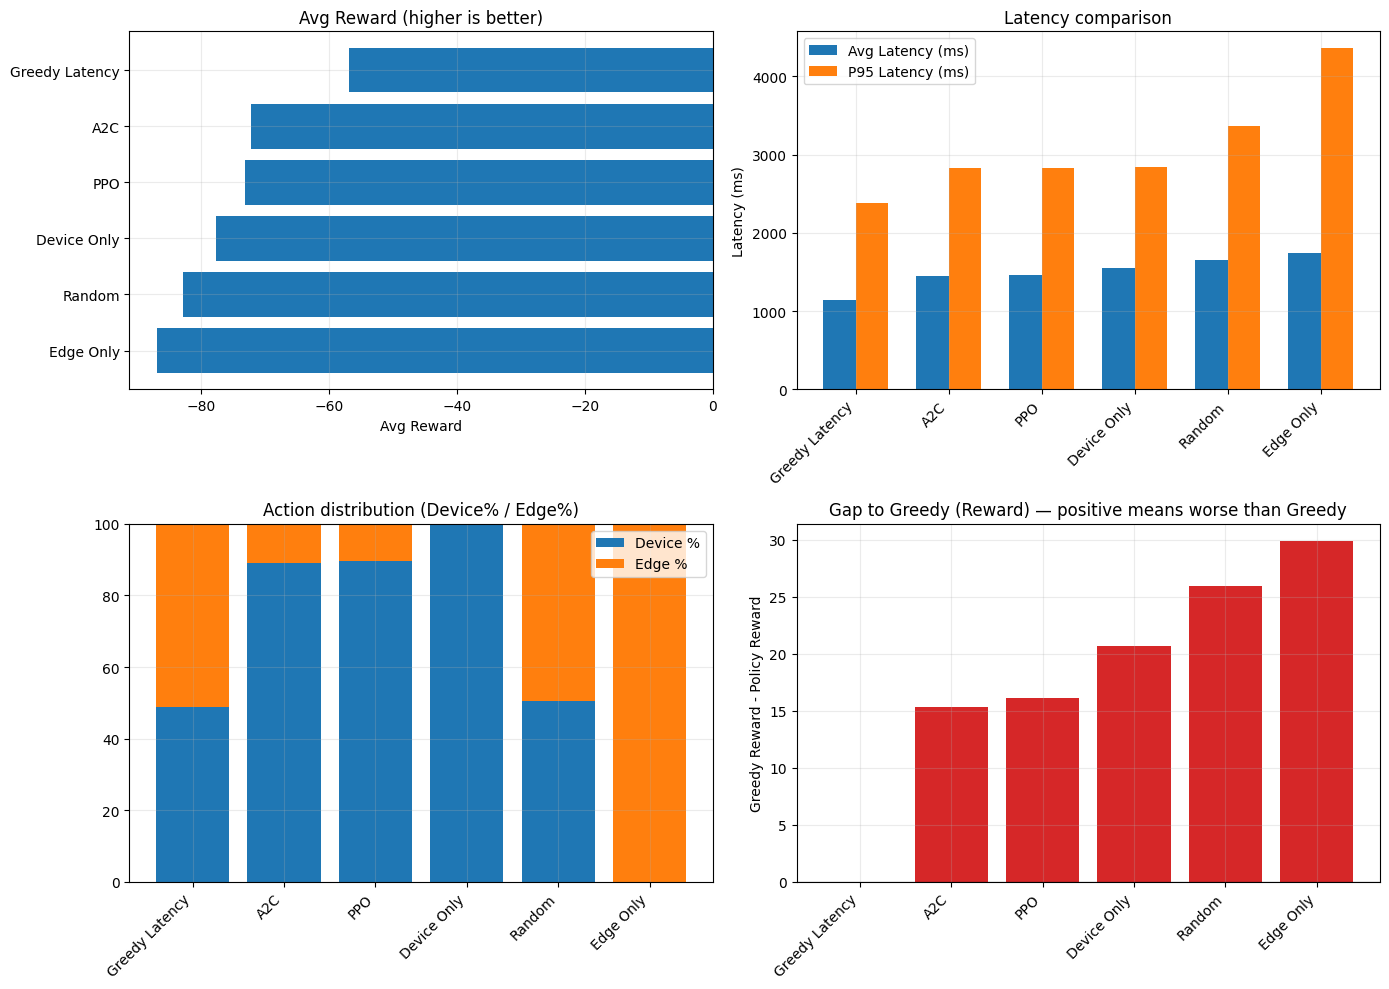

Plots saved to ./logs/comparison_plots.png


In [33]:
# ============================================================================
# Build comprehensive comparison table and plots
# ============================================================================

print("\nBuilding comparison table for all policies and trained models...")

# Keep the evaluation budget in one place so the table stays in sync.
eval_episodes = 200

# env factory used for evaluate_edge_policy
env_fn = lambda seed: EdgeOffloadingEnv(max_steps=50)

# 1) Baseline policies
policies = {
    'Random': random_policy,
    'Device Only': device_only_policy,
    'Edge Only': edge_only_policy,
    'Greedy Latency': greedy_latency_policy,
}

baseline_results = {}
for name, fn in policies.items():
    print(f"Evaluating baseline: {name}")
    baseline_results[name] = evaluate_edge_policy(env_fn, fn, episodes=eval_episodes)

# 2) Load trained models and create action functions
model_results = {}

# Helper to load SB3 model safely
from stable_baselines3.common.base_class import BaseAlgorithm

# A2C
try:
    a2c_model_path = './logs/a2c_best/best_model.zip'
    a2c = A2C.load(a2c_model_path)
    print('Loaded A2C best model from', a2c_model_path)
except Exception:
    a2c = None
    try:
        a2c = A2C.load('a2c_edgeoffloading_tuned_hp')
        print('Loaded A2C fallback model a2c_edgeoffloading_tuned_hp')
    except Exception:
        print('A2C model not found.')

if a2c is not None:
    def a2c_action_fn(state, env):
        action, _ = a2c.predict(state, deterministic=True)
        return int(action)
    print('Evaluating A2C...')
    model_results['A2C'] = evaluate_edge_policy(env_fn, a2c_action_fn, episodes=eval_episodes)

# PPO
try:
    ppo_model_path = './logs/ppo_best/best_model.zip'
    ppo = PPO.load(ppo_model_path)
    print('Loaded PPO best model from', ppo_model_path)
except Exception:
    ppo = None
    try:
        ppo = PPO.load('ppo_edgeoffloading_tuned_hp')
        print('Loaded PPO fallback model ppo_edgeoffloading_tuned_hp')
    except Exception:
        print('PPO model not found.')

if ppo is not None:
    def ppo_action_fn(state, env):
        action, _ = ppo.predict(state, deterministic=True)
        return int(action)
    print('Evaluating PPO...')
    model_results['PPO'] = evaluate_edge_policy(env_fn, ppo_action_fn, episodes=eval_episodes)

all_results = {**baseline_results, **model_results}

rows = []
for name, res in all_results.items():
    rows.append({
        'Policy': name,
        'Avg Latency (ms)': float(res['avg_latency']),
        'P95 Latency (ms)': float(res['p95_latency']),
        'Avg Reward': float(res['avg_reward']),
        'Std Return': float(np.std(res['episode_rewards'], ddof=1)) if len(res['episode_rewards']) > 1 else 0.0,
        'Max Return': float(np.max(res['episode_rewards'])) if len(res['episode_rewards']) > 0 else np.nan,
        'Device %': float(res['device_pct']),
        'Edge %': float(res['edge_pct']),
        'Num Episodes': int(len(res['episode_rewards']))
    })

import pandas as pd
df = pd.DataFrame(rows)

# Compute Gap to Greedy (Avg Reward and Avg Latency)
if 'Greedy Latency' in df['Policy'].values:
    greedy_row = df[df['Policy'] == 'Greedy Latency'].iloc[0]
    df['Gap to Greedy (Reward)'] = greedy_row['Avg Reward'] - df['Avg Reward']
    df['Gap to Greedy (Latency ms)'] = df['Avg Latency (ms)'] - greedy_row['Avg Latency (ms)']
else:
    df['Gap to Greedy (Reward)'] = pd.NA
    df['Gap to Greedy (Latency ms)'] = pd.NA

# Sort by Avg Reward descending (higher is better)
df = df.sort_values(by='Avg Reward', ascending=False).reset_index(drop=True)

# Display
from IPython.display import display
print('\nComparison table:')
display(df)

# Save to CSV
out_csv = './logs/comparison_table.csv'
df.to_csv(out_csv, index=False)
print(f'Comparison table saved to {out_csv}')

# Also print concise summary
print('\nConcise summary:')
for _, row in df.iterrows():
    print(f"- {row['Policy']}: AvgLat={row['Avg Latency (ms)']:.2f}ms, P95={row['P95 Latency (ms)']:.2f}ms, AvgR={row['Avg Reward']:.3f}, StdR={row['Std Return']:.3f}, MaxR={row['Max Return']:.3f}, Device%={row['Device %']:.1f}%, Edge%={row['Edge %']:.1f}%, GapR={row['Gap to Greedy (Reward)']:.3f}")

# ---------- PLOTTING ----------
import matplotlib.pyplot as plt
import numpy as np

policies = df['Policy'].tolist()
indices = np.arange(len(policies))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Avg Reward (horizontal bar)
ax = axes[0,0]
ax.barh(policies, df['Avg Reward'], color='C0')
ax.set_title('Avg Reward (higher is better)')
ax.set_xlabel('Avg Reward')
ax.invert_yaxis()

# 2) Avg Latency and P95 (grouped bar)
ax = axes[0,1]
width = 0.35
ax.bar(indices - width/2, df['Avg Latency (ms)'], width, label='Avg Latency (ms)')
ax.bar(indices + width/2, df['P95 Latency (ms)'], width, label='P95 Latency (ms)')
ax.set_xticks(indices)
ax.set_xticklabels(policies, rotation=45, ha='right')
ax.set_title('Latency comparison')
ax.set_ylabel('Latency (ms)')
ax.legend()

# 3) Device% vs Edge% (stacked)
ax = axes[1,0]
device = df['Device %']
edge = df['Edge %']
ax.bar(indices, device, label='Device %')
ax.bar(indices, edge, bottom=device, label='Edge %')
ax.set_xticks(indices)
ax.set_xticklabels(policies, rotation=45, ha='right')
ax.set_title('Action distribution (Device% / Edge%)')
ax.set_ylim(0, 100)
ax.legend()

# 4) Gap to Greedy (Avg Reward)
ax = axes[1,1]
ax.bar(indices, df['Gap to Greedy (Reward)'], color='C3')
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks(indices)
ax.set_xticklabels(policies, rotation=45, ha='right')
ax.set_title('Gap to Greedy (Reward) — positive means worse than Greedy')
ax.set_ylabel('Greedy Reward - Policy Reward')

plt.tight_layout()
plt.savefig('./logs/comparison_plots.png', dpi=150)
plt.show()
print('Plots saved to ./logs/comparison_plots.png')

## CONGRATULATIONS TEAM!

Congratulations on Completing **Lab 05.2 – Continuous and Policy-Based RL with DDPG and PPO**!

**Key Conclusions:**

- You successfully designed and validated an **EdgeOffloadingEnv** that models realistic latency-aware offloading decisions.
- Baseline policies (random, device-only, edge-only, greedy) provided strong reference points for RL performance.
- **Actor-Critic/A2C-style methods** improved learning stability versus pure policy-gradient updates.
- **PPO** demonstrated robust and sample-efficient policy improvement through clipped objective optimization.
- Across experiments, learned policies captured the core trade-off between **local execution cost** and **edge transmission/queue delay**.

**Why This Lab Is Important:**

- It connects RL theory to a practical networking scenario: adaptive edge offloading.
- It shows how policy-based methods can outperform static heuristics in dynamic environments.
- It builds a strong foundation for deploying more advanced RL approaches in real-world edge/cloud systems.

### References

- Schulman et al., Proximal Policy Optimization Algorithms, arXiv:1707.06347
- Schulman et al., High-Dimensional Continuous Control Using GAE, ICLR 2016
- PyTorch documentation: https://pytorch.org/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026